## Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Airbnb NYC Listings dataset

2. My label is price_category. I am prediciting whether an Airbnb listing belongs to high-price or low-price category. This is a binary classification problem

3. I Plan to use features such as room type, neighborhood, host response rate, host acceptance rate, review scores, availiability, minimum nights, number of reviews, reviews per month, and host verification information because they may influence whether a listing is classified as high-priced or low-priced. I may remove features that are irrelevant or contain too many missing values after exploring the data.

4. A model that predicts whether an Airbnb listing is high-priced can help analysts quickly identify premium listings without manually reviewing every property. This can improve consistency, reduce the time spent evaluating listings, and support better investment and marketing decisions.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [3]:
#check class imbalance
df["price_category"].value_counts()

low     20785
high     7237
Name: price_category, dtype: int64

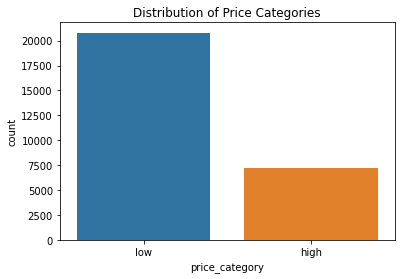

In [4]:
#visualize class distributions
sns.countplot(data=df, x = "price_category")
plt.title("Distribution of Price Categories")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [5]:
df.info() 

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28022 entries, 0 to 28021
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          28017 non-null  object 
 1   description                                   27452 non-null  object 
 2   neighborhood_overview                         18206 non-null  object 
 3   host_name                                     28022 non-null  object 
 4   host_location                                 27962 non-null  object 
 5   host_about                                    17077 non-null  object 
 6   host_response_rate                            16179 non-null  float64
 7   host_acceptance_rate                          16909 non-null  float64
 8   host_is_superhost                             28022 non-null  bool   
 9   host_listings_count                           28022 non-null 

name                                                5
description                                       570
neighborhood_overview                            9816
host_name                                           0
host_location                                      60
host_about                                      10945
host_response_rate                              11843
host_acceptance_rate                            11113
host_is_superhost                                   0
host_listings_count                                 0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bedrooms                                         2918
beds                        

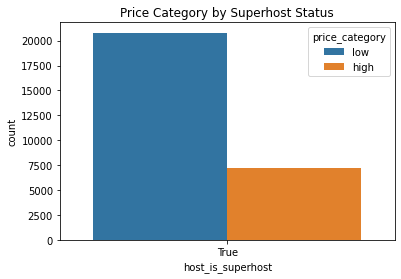

In [6]:
sns.countplot(data=df, x="host_is_superhost", hue="price_category")
plt.title("Price Category by Superhost Status")
plt.show()

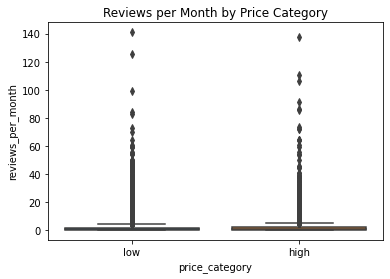

In [7]:
sns.boxplot(data=df, x="price_category", y="reviews_per_month")
plt.title("Reviews per Month by Price Category")
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

During my exploratory analysis, I found that the dataset contains 28,022 Airbnb listings with 51 features, including numerical, categorical, and Boolean variables. The target variable, price_category, is moderately imbalanced, with more low-price listings (20,785) than high-price listings (7,237). I also found that several columns contain missing values, particularly host_response_rate, host_acceptance_rate, host_about, neighborhood_overview, bedrooms, and beds, which will need to be handled during data preparation. The visualizations showed differences between price categories and features such as reviews per month, and the boxplot also revealed several outliers. Based on these findings, I plan to handle missing values, remove or ignore irrelevant text features, encode categorical variables, and evaluate my model using both accuracy and F1 score because of the class imbalance.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The dataset may contain bias because factors such as neighborhood can reflect historical and economic differences across New York. Features like neighborhood, host response rate, and review scores may indirectly reflect socioeconomic conditions rather than only the quality of a listing. If the model relies too heavily on these features, it could reinforce existing patterns in the data.

2. Hosts can be affected if the model incorrectly classifies their listing as low priced when it should be high-priced, or vice versa. These prediction errors could influence investment decisions, marketing strategies, or how listings are prioritized. Hosts in neighborhoods with fewer listings or different economic conditions may be affected more if the model learns biased patterns.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [8]:
df_model = df.copy() #copy original data

In [9]:
df_model["price_category"]  = df_model["price_category"].map({ #convert the label to numbers
    "low": 0,
    "high": 1
})

In [10]:
#fill missing numeric values
numeric_cols = [
    "host_response_rate",
    "host_acceptance_rate",
    "bedrooms",
    "beds"
]

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

In [11]:
#keep only manageable, useful features
features_to_keep = [
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_listings_count",
    "neighbourhood_group_cleansed",
    "room_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_value",
    "instant_bookable",
    "reviews_per_month",
    "n_host_verifications",
    "price_category"
]

df_model = df_model[features_to_keep]

#convert categorical and boolean columns to numeric
df_model = pd.get_dummies(df_model, drop_first=True)

#check results
print("Missing values:", df_model.isnull().sum().sum())
print("Shape:", df_model.shape)
df_model.head()

Missing values: 0
Shape: (28022, 25)


,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,accommodates,bathrooms,bedrooms,beds,minimum_nights,availability_365,...,reviews_per_month,n_host_verifications,price_category,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,0.80,0.17,True,8.0,1,1.0,1.0,1.0,30,338,...,0.33,9,0,0,1,0,0,0,0,0
1,0.09,0.69,True,1.0,3,1.0,1.0,3.0,1,194,...,4.86,6,0,1,0,0,0,0,0,0
2,1.00,0.25,True,1.0,4,1.5,2.0,2.0,5,123,...,0.02,3,1,1,0,0,0,0,0,0
3,1.00,1.00,True,1.0,2,1.0,1.0,1.0,2,192,...,3.68,4,0,0,1,0,0,0,1,0
4,1.00,0.91,True,1.0,1,1.0,1.0,1.0,2,0,...,0.87,7,0,0,1,0,0,0,1,0


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I created a copy of the original dataset so the original data remained unchanged. I converted the target variable, price_category, into binary values where low = 0 and high = 1. I filled missing values in host_response_rate, host_acceptance_rate, bedrooms, and beds using the median because these are numeric features and the median is less affected by outliers. I selected relevant features related to host characteristics, properly information, review scores, avaliability, and location. I then used one-hot ecoding to convert categorical variables such as neighborhood and room type into numeric columns that can be used by machine learning models. After preprocessing, the modeling dataset contained no missing values.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [12]:
# Create labeled examples from the dataset

# Features (X) and label (y)

X = df_model.drop("price_category", axis=1)
y = df_model["price_category"]

print (X.shape)
print(y.shape)

(28022, 24)
(28022,)


In [13]:
# Create training and test sets out of the labeled examples 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(22417, 24)
(5605, 24)


In [14]:
# Train, test and evaluate your model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=2000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [15]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model

from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "max_iter": [500, 1000]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring ="f1"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'C': 1, 'max_iter': 500}
Best Cross Validation Score: 0.5641327043919099


In [16]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.

from sklearn.metrics import accuracy_score, f1_score

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="binary")

print("Accuracy:", accuracy)
print("F1 Score", f1)

Accuracy: 0.8114183764495986
F1 Score 0.5568134171907757


In [17]:
# Interpret your model's outputs 
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by = "Coefficient",
    key=abs,
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
18,neighbourhood_group_cleansed_Manhattan,1.092689
4,accommodates,0.706756
22,room_type_Private room,-0.630905
17,neighbourhood_group_cleansed_Brooklyn,0.524025
8,minimum_nights,-0.435652
6,bedrooms,0.325204
5,bathrooms,0.280981
12,review_scores_cleanliness,0.238405
13,review_scores_value,-0.212008
10,number_of_reviews,-0.201134


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose Logistic Regression because the goal of this project was to predict whether an Airbnb listing belonged to the low-price or high-price category, making it a binary classification problem. Logistic Regression is well suited for binary classification, is easy to interpret, and allows me to understand how each feature affects the prediction.

2. I used GridSearch CV to test different values of the regularization parameter (C) and the maximum number of iterations (max_iter). The best model used C = 1 and max_iter = 500, giving the highest cross-validation F1 score. This showed that testing multiple hyperparameters can improve model performance instead of relying on default settings.

3. I interpreted the logistic regression coefficients to understand which features had the strongest influence on predicting whether an Airbnb listing belonged to the high-price category. Positive coefficients increased that likelihood, while negative coefficents decreased that likelihood. For example, listings located in Manhattan and listings that accommodate more guests had positive coefficientsm, making them more likely to be classified as high-priced. In contrast, private rooms and listings with higher minimum nights had negative coefficients, making them less likely to be classified as high-priced. The model achieved an accuracy of about 81.1% and an F1 score of about 0.56, showing that it performed well overall but had more difficulty identifying the minority high-price class.

4. Yes the model may unintentionally reflect paterns present in the historical Airbnb data. For example, listings in certain neighborhoods such as Manhattan may consistently receive higher predicted prices because of location rather than the quality of the listing itself. Incorrect predictions could affect hosts if the model should therefore be used as a decision-support tool rather than the sole basis for pricing decisions.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [18]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [19]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))
# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
nn_model.add(keras.layers.Dense(32, activation="relu"))
nn_model.add(keras.layers.Dense(16, activation="relu"))
# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(1, activation="sigmoid"))

# Print a summary of your model
nn_model.summary()

# I chose two hidden layer's with 32 units in the first layer and 16 units
# In the second layer. This gives the model enough capacity to learn
# nonlinear relationships without making the network unecessarily large. 
# I used ReLU activation because it is effective for hidden layers and helps 
# the model learn complex patterns efficiently.

#I used one ouput unit with sigmoid activation because this is a binary
# classification problem. Sigmoid produces a probability between 0 and 1.

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                800       
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 1,345
Trainable params: 1,345
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [20]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# I chose a learning rate of 0.01 because it is a moderate starting value.
# It should allow the model to learn steadily without making weight updates
# that are too large.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [21]:
# I used binary cross-entropy because the model is predictiing one of two
# classes:low-price or high_price. from_logits=False is used because the
#output layer already applies sigmoid activation.

loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [22]:
# I compiled the model using the SGD optimizer, binary cross-entropy loss.
# and accuracy as the training metroc
nn_model.compile(
    optimizer=sgd_optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [23]:
# Decision: How many epochs? Add a comment.

# I chose 100 epochs to give the model enough time to learn.
# The validation split will help me monitor whether the model begins to overfit.

import time 

t0 = time.time() # start time

num_epochs = 100 

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/100
561/561 [==============================] - 4s 5ms/step - loss: 0.5008 - accuracy: 0.7793 - val_loss: 0.4460 - val_accuracy: 0.7855
Epoch 2/100
561/561 [==============================] - 2s 4ms/step - loss: 0.4174 - accuracy: 0.8061 - val_loss: 0.4264 - val_accuracy: 0.7917
Epoch 3/100
561/561 [==============================] - 2s 4ms/step - loss: 0.4037 - accuracy: 0.8124 - val_loss: 0.4184 - val_accuracy: 0.7973
Epoch 4/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3962 - accuracy: 0.8183 - val_loss: 0.4115 - val_accuracy: 0.8020
Epoch 5/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3908 - accuracy: 0.8211 - val_loss: 0.4063 - val_accuracy: 0.8087
Epoch 6/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3861 - accuracy: 0.8232 - val_loss: 0.4025 - val_accuracy: 0.8095
Epoch 7/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3823 - accuracy: 0.8253 - val_loss: 0.3998 - val_accuracy: 0.8120

Epoch 58/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3417 - accuracy: 0.8481 - val_loss: 0.3674 - val_accuracy: 0.8327
Epoch 59/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3413 - accuracy: 0.8484 - val_loss: 0.3669 - val_accuracy: 0.8310
Epoch 60/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3413 - accuracy: 0.8487 - val_loss: 0.3692 - val_accuracy: 0.8343
Epoch 61/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3408 - accuracy: 0.8480 - val_loss: 0.3676 - val_accuracy: 0.8327
Epoch 62/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3404 - accuracy: 0.8485 - val_loss: 0.3666 - val_accuracy: 0.8336
Epoch 63/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3401 - accuracy: 0.8498 - val_loss: 0.3675 - val_accuracy: 0.8339
Epoch 64/100
561/561 [==============================] - 2s 4ms/step - loss: 0.3401 - accuracy: 0.8493 - val_loss: 0.3678 - val_accuracy:

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



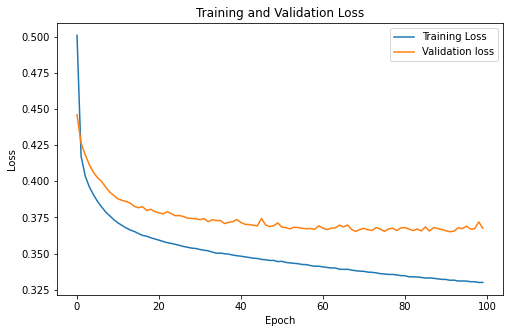

In [24]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation loss")

# Plot training accuracy and validation accuracy over epochs
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()


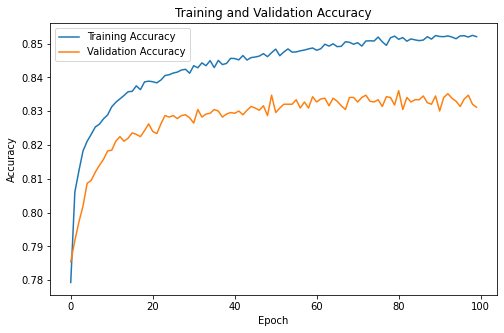

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

# Plot training accuracy and validation accuracy over epochs

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()


### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [26]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE
from sklearn.metrics import accuracy_score, f1_score

#prediction
y_prob = nn_model.predict(X_test_scaled)

#covert
y_pred = (y_prob >= 0.5).astype(int)

In [27]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, y_pred)
nn_f1 = f1_score(y_test, y_pred)

print("Neural Nework Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1)

Neural Nework Accuracy: 0.8330062444246209
Neural Network F1 Score: 0.6207455429497569


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I built a neural network with two hidden layers. The first hidden layer had 32 units, and the second has 16 units. I used ReLU activation in both the hidden layers because it helped the network learn nonlinear relationships efficiently. I used one output unit with sigmoid activation because this is a binary classification problem. I selected stochastic gradient descent with a learning rate of 0.01 and trained the model for 100 epochs.  I chose these settings to give the model enough capacity to learn without making the network unnecessarily large.

2. The training and validation loss both decreased over time, while training and validation accuracy increased. The curve remained fairly close to each other, which suggests that the model learned useful patterns and generalized reasonably well. I did not observe strong signs of overfitting because the validation performance did not become much worse than the training performace.

3. The neural network achieved an accuracy of approximately by 0.833( 83.3%), meaning it correctly classified about 83 out of every 100 Airbnb listings in the test dataset. It also achieved an F1 Score of approximately 0.621, indicating better overall performance at identifying both low- and high-price listings than the logistic regression model. These results were consistent with the training curves, which showed increasing accuracy and decreasing loss with only a small gap between training and validation performance.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [28]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
results = pd.DataFrame({
   'Metric': ['Accuracy', 'F1 Score'],
    "Logistic Regression": [
       accuracy,
        f1
    ],
    "Neural Network": [
        nn_accuracy,
        nn_f1
    ]
})

print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.811418        0.833006
 F1 Score             0.556813        0.620746


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The neural network performed better than the logistic regression model on both evaluation metrics. The logistic regression model achieved an accuracy of 0.811 and an F1 score of 0.557, while the neural network achieved an accuracy of 0.833 and an F1 score of 0.621. Both accuracy and F1 score improved with the neural network, indicating that it was better at correctly classifying listings overall and identifying the minority high-price class. None of the evaluation metrics stayed the same or became worse.

2. Although the neural network was more complex to build, train, and interpret, I believe the additional complexity was justified because it produced noticeably better performance than logistic regression. The improvement in F1 score was especially valuable because the dataset contained class imbalance, making it important to correctly identify high-price listings rather than only maximizing overall accuracy.

3. If I were presenting this work to the company and its client, I would recommend deploying the neural network because it achieved the highest accuracy (83.3%) and F1 score (0.621). Although it required more training time and less interpretable than logistic regression, and improved performance justified the added complexity for this prediction task. 

4. If I had more time, I would experiment with different neural network architectures, learning rates, and optimizers such as Adam. I would also test techniques to address class imbalance, including class weighting or oversampling, and evaluate additional metrics such as precision, recall, and the confusion matrix. Finally, I would explore additional feature engineering and hyperparameter tuning to determine whether the model;s performance could be improved even further.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used AI throughout the capstone primarily for debugging, reviewing my code, and improving my written explanations, After completing sections on my own, I used AI to help identify coding errors, explain machine learning concepts that I was unsure about, and review my reflections for clarity and grammar. I also used AI to verify that my code outputs matched my written interpretations and to better understand why models produced certain results.

2. The neural network portion required the most effort because it involved building the model architecture, selecting hyperparamters, training the network, and interpreting the results. I also encountered coding errors during training and evaluation that required debugging. I  used AI to help identify those issues and explain why they occurred, but I made the corrections myself and verified that the updated code produced reasonable results.

3. I verified my work by restarting the notebook and running every cell from beginning to end, confirming that the code executed without errors and that printed evaluation metrics matched my written interpretations. I also compared the training curves, model outputs, and summary table to ensure everything was consistent before submitting.

4. Next time, I would test my code more frequently instead of waiting untill later sections of the project to debug multiple issues at once. I would also verify my evaluation metrics immediately after each model's was trained so that my written reflections stayed consistent with my results throughout the project.